In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
iris = load_iris()
X = iris.data          # Features
y = iris.target        # Target labels
print("Feature Names:", iris.feature_names)
print("Target Names:", iris.target_names)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = SVC(
    kernel='rbf',      # Kernel type
    C=1.0,             # Regularization parameter
    gamma='scale',     # Kernel coefficient
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target Names: ['setosa' 'versicolor' 'virginica']

Accuracy: 0.9666666666666667

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



C:\Users\POLY SIL\AppData\Local\Temp\ipykernel_11788\1448838952.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left')


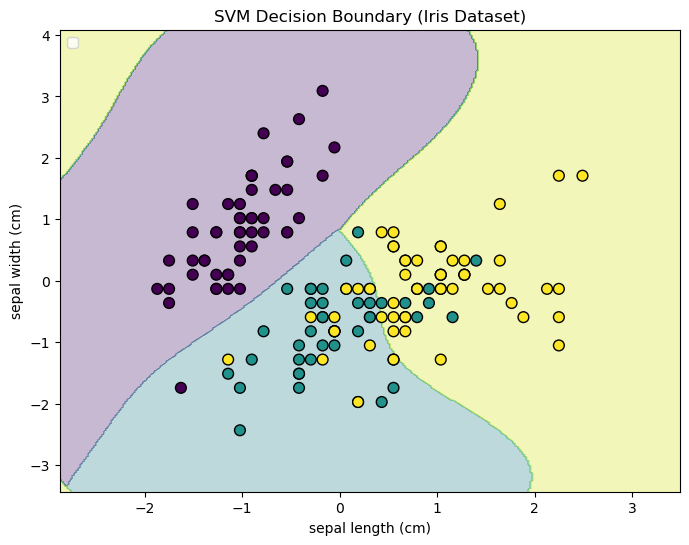

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
iris = load_iris()
X = iris.data[:, :2]
y = iris.target
scaler = StandardScaler()
X = scaler.fit_transform(X)
model = SVC(kernel='rbf', C=1.0, gamma='scale')
model.fit(X, y)
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    edgecolor='k',
    s=60
)
plt.scatter(
    X[y==0,0], X[y==0,1],
    color='red',
    edgecolor='k',
    s=60,
    marker='o',
    label='Setosa'
)

plt.scatter(
    X[y==1,0], X[y==1,1],
    color='green',
    edgecolor='k',
    s=60,
    marker='s',
    label='Versicolor'
)

plt.scatter(
    X[y==2,0], X[y==2,1],
    color='blue',
    edgecolor='k',
    s=60,
    marker='^',
    label='Virginica'
)
plt.legend(loc='upper left')
plt.title("SVM Decision Boundary (Iris Dataset)")
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.show()